# Checking the Emission Line Ratios from the EmFit Catalog

In notebook `emfit-vac.ipynb` I download a sample of spectra into `../data/spectra/`. I will do my own measurements of their line ratios to double check that these are reliable.

In [1]:
%matplotlib widget

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

In [3]:
emps = Table.read('../data/emp-candidates.fits', format='fits').to_pandas()

In [4]:
targetid = emps['TARGETID'].loc[0]
z = emps['Z'].loc[0]
spec = Table.read(f'../data/spectra/{targetid}.fits', format='fits')

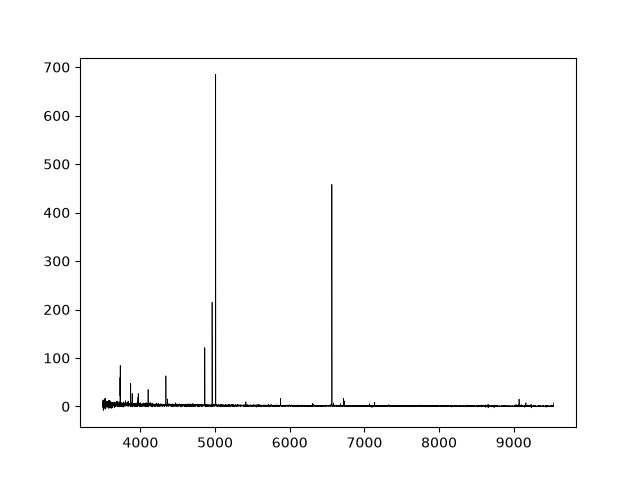

In [5]:
plt.figure(1)
plt.clf()

plt.plot(spec['wavelength'] / (1 + z), spec['flux'], color='black', lw=0.5)


plt.show()

In [6]:
ha_window = [(6450, 6500), (6600, 6650)]
rest_wave = [6548.1, 6562.8, 6583.4]

def ha_model(z, sigma, flux_ha, flux_n2_a, flux_n2_b, m, n, wave):
    obs_wave = wave * (1 + z)
    ha = flux_ha * np.sqrt(2 * np.pi) * sigma * np.exp(-0.5 * ((obs_wave - 6562.8) / sigma) ** 2)
    n2_a = flux_n2_a * np.sqrt(2 * np.pi) * sigma * np.exp(-0.5 * ((obs_wave - 6548.1) / sigma) ** 2)
    n2_b = flux_n2_b * np.sqrt(2 * np.pi) * sigma * np.exp(-0.5 * ((obs_wave - 6583.4) / sigma) ** 2)
    return ha + n2_a + n2_b + m * obs_wave + n

In [7]:
mask = ((spec['wavelength'] / (1 + z) > ha_window[0][0]) & (spec['wavelength'] / (1 + z) < ha_window[1][1]))
mask_w1 = (spec['wavelength'] / (1 + z) > ha_window[0][0]) & (spec['wavelength'] / (1 + z) < ha_window[0][1])
mask_w2 = (spec['wavelength'] / (1 + z) > ha_window[1][0]) & (spec['wavelength'] / (1 + z) < ha_window[1][1])

# first guesses for the parameters
z = emps['Z'].loc[0]
center_windows = [0.5 * (ha_window[0][0] + ha_window[0][1]),
                  0.5 * (ha_window[1][0] + ha_window[1][1])]
flux_windows = [np.mean(spec['flux'][mask_w1]), np.mean(spec['flux'][mask_w2])]
m = (flux_windows[1] - flux_windows[0]) / (center_windows[1] - center_windows[0])
n = flux_windows[0] - m * center_windows[0]
sigma = 1.
flux_ha = spec['flux'][mask].max() * 1.5
flux_n1_a = flux_ha / 100
flux_n2_b = flux_ha / 100

In [8]:
ha_model(z, sigma, flux_ha, flux_n1_a, flux_n2_b, m, n, 6562.8 / (1 + z))

1723.9481284843646

In [9]:
 spec['wavelength'][mask]

6648.000000000202
6648.800000000202
6649.600000000202
6650.400000000202
6651.200000000203
6652.000000000203
6652.800000000203
6653.600000000203
6654.400000000203
6655.2000000002035
6656.000000000204


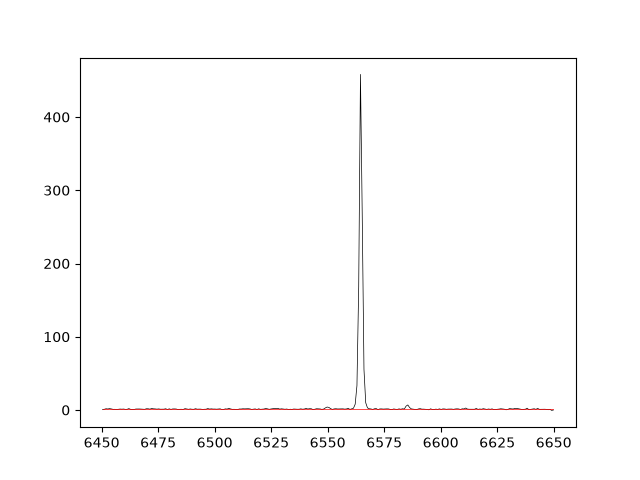

In [10]:
plt.figure(2)
plt.clf()

plt.plot(spec['wavelength'][mask] / (1 + z), spec['flux'][mask], color='black', lw=0.5)

plt.plot(spec['wavelength'][mask] / (1 + z), ha_model(z, sigma, flux_ha, flux_n1_a, flux_n2_b, m, n, spec['wavelength'][mask] / (1 + z)), color='red', lw=0.5)

plt.show()